In [2]:
import pandas as pd 
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
tabela = pd.read_csv('../data/01-raw/credit_risk_dataset.csv')

tabela

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
tabela.rename(columns={
    'person_age':'idade_da_pessoa',
    'person_income':'renda_da_pessoa',
    'person_home_ownership':'propriedade_da_casa_da_pessoa',
    'person_emp_length':'tempo_de_emprego_da_pessoa',
    'loan_intent':'intenção_de_empréstimo',
    'loan_grade':'classificação_de_crédito',
    'loan_amnt':'valor_do_empréstimo',
    'loan_int_rate':'taxa_de_juros_do_empréstimo',
    'loan_status':'status_do_empréstimo',
    'loan_percent_income':'percentual_da_renda_do_empréstimo',
    'cb_person_default_on_file':'inadimplência_da_pessoa_registrada_no_arquivo_cb',
    'cb_person_cred_hist_length':'histórico_de_crédito_da_pessoa_no_arquivo_cb'
},inplace=True)

In [5]:
tabela.head()

,idade_da_pessoa,renda_da_pessoa,propriedade_da_casa_da_pessoa,tempo_de_emprego_da_pessoa,intenção_de_empréstimo,classificação_de_crédito,valor_do_empréstimo,taxa_de_juros_do_empréstimo,status_do_empréstimo,percentual_da_renda_do_empréstimo,inadimplência_da_pessoa_registrada_no_arquivo_cb,histórico_de_crédito_da_pessoa_no_arquivo_cb
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
tabela.columns = tabela.columns.str.strip().str.lower()

In [7]:
tabela = tabela.drop_duplicates()

In [8]:
tabela['propriedade_da_casa_da_pessoa']  = tabela['propriedade_da_casa_da_pessoa'].str.lower()
tabela['intenção_de_empréstimo']  = tabela['intenção_de_empréstimo'].str.lower()
tabela['classificação_de_crédito']  = tabela['classificação_de_crédito'].str.lower()
tabela['inadimplência_da_pessoa_registrada_no_arquivo_cb']  = tabela['inadimplência_da_pessoa_registrada_no_arquivo_cb'].str.lower()

In [9]:
tabela

,idade_da_pessoa,renda_da_pessoa,propriedade_da_casa_da_pessoa,tempo_de_emprego_da_pessoa,intenção_de_empréstimo,classificação_de_crédito,valor_do_empréstimo,taxa_de_juros_do_empréstimo,status_do_empréstimo,percentual_da_renda_do_empréstimo,inadimplência_da_pessoa_registrada_no_arquivo_cb,histórico_de_crédito_da_pessoa_no_arquivo_cb
0,22,59000,rent,123.0,personal,d,35000,16.02,1,0.59,y,3
1,21,9600,own,5.0,education,b,1000,11.14,0,0.10,n,2
2,25,9600,mortgage,1.0,medical,c,5500,12.87,1,0.57,n,3
3,23,65500,rent,4.0,medical,c,35000,15.23,1,0.53,n,2
4,24,54400,rent,8.0,medical,c,35000,14.27,1,0.55,y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,mortgage,1.0,personal,c,5800,13.16,0,0.11,n,30
32577,54,120000,mortgage,4.0,personal,a,17625,7.49,0,0.15,n,19
32578,65,76000,rent,3.0,homeimprovement,b,35000,10.99,1,0.46,n,28
32579,56,150000,mortgage,5.0,personal,b,15000,11.48,0,0.10,n,26


In [10]:
tabela.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   idade_da_pessoa                                   32416 non-null  int64  
 1   renda_da_pessoa                                   32416 non-null  int64  
 2   propriedade_da_casa_da_pessoa                     32416 non-null  str    
 3   tempo_de_emprego_da_pessoa                        31529 non-null  float64
 4   intenção_de_empréstimo                            32416 non-null  str    
 5   classificação_de_crédito                          32416 non-null  str    
 6   valor_do_empréstimo                               32416 non-null  int64  
 7   taxa_de_juros_do_empréstimo                       29321 non-null  float64
 8   status_do_empréstimo                              32416 non-null  int64  
 9   percentual_da_renda_do_empréstimo

In [11]:
tabela.isnull().sum()

idade_da_pessoa                                        0
renda_da_pessoa                                        0
propriedade_da_casa_da_pessoa                          0
tempo_de_emprego_da_pessoa                           887
intenção_de_empréstimo                                 0
classificação_de_crédito                               0
valor_do_empréstimo                                    0
taxa_de_juros_do_empréstimo                         3095
status_do_empréstimo                                   0
percentual_da_renda_do_empréstimo                      0
inadimplência_da_pessoa_registrada_no_arquivo_cb       0
histórico_de_crédito_da_pessoa_no_arquivo_cb           0
dtype: int64

In [12]:
tabela.dropna(inplace=True)

In [13]:
tabela.isnull().sum()

idade_da_pessoa                                     0
renda_da_pessoa                                     0
propriedade_da_casa_da_pessoa                       0
tempo_de_emprego_da_pessoa                          0
intenção_de_empréstimo                              0
classificação_de_crédito                            0
valor_do_empréstimo                                 0
taxa_de_juros_do_empréstimo                         0
status_do_empréstimo                                0
percentual_da_renda_do_empréstimo                   0
inadimplência_da_pessoa_registrada_no_arquivo_cb    0
histórico_de_crédito_da_pessoa_no_arquivo_cb        0
dtype: int64

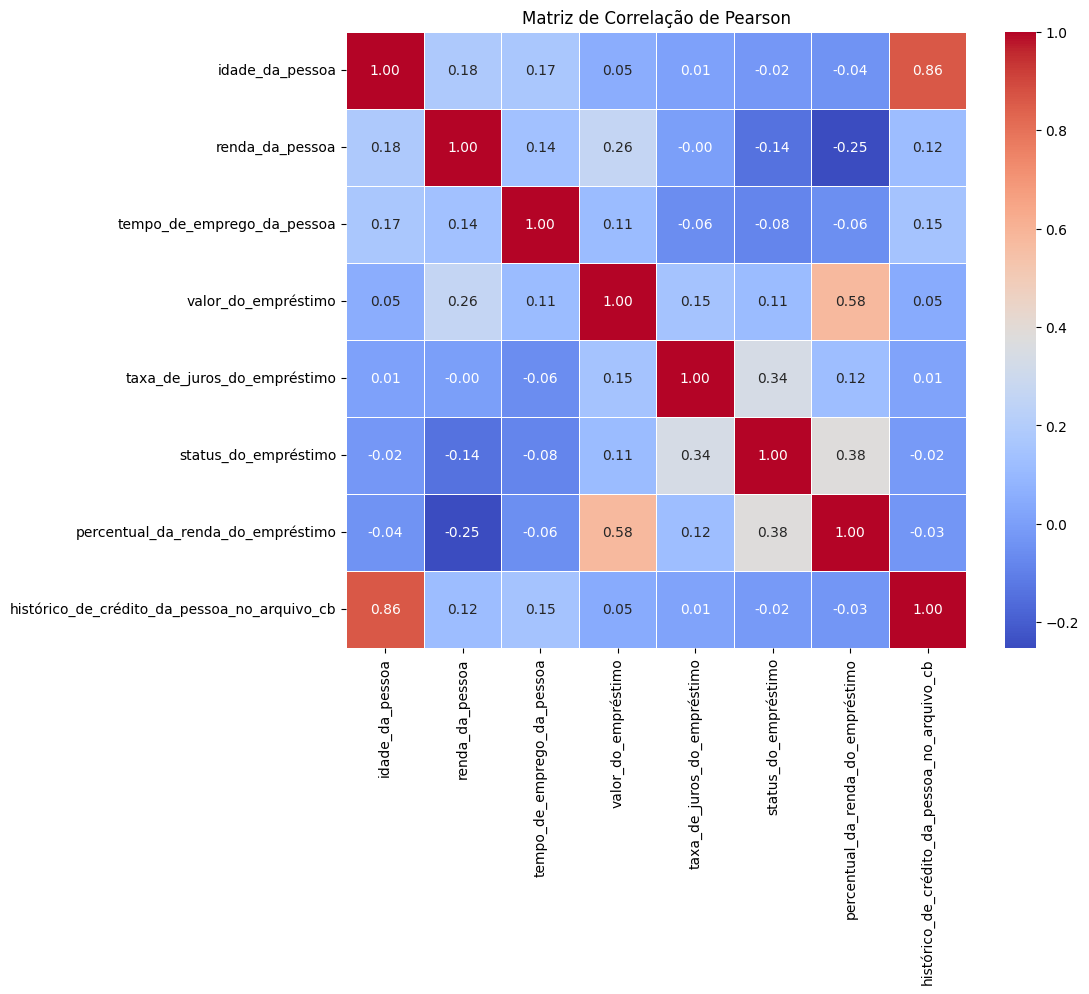

In [14]:
# Calcular correlação de Pearson
correlacao = tabela.corr(method='pearson',numeric_only=True)

# Configurar tamanho da figura
plt.figure(figsize=(10, 8))

# Criar heatmap com seaborn
sns.heatmap(
    correlacao,
    annot=True,       # mostra os valores
    cmap='coolwarm',  # paleta de cores
    fmt='.2f',        # duas casas decimais
    linewidths=0.5
)

# Título
plt.title("Matriz de Correlação de Pearson")

# Exibir gráfico
plt.show()

In [16]:
tabela['status_do_empréstimo'].value_counts(normalize=True)

status_do_empréstimo
0    0.782885
1    0.217115
Name: proportion, dtype: float64